# SEEM3650 Practical Exam - BabyGPT with nanoGPT

**Student ID:** 1155213983  
**Last three digits (XYZ):** 983  
**XYZ mod 4:** 3, so Step 3 fixes `n_head = 4` and varies `n_layer in {2, 3, 5, 7}`.  
**XYZ mod 2:** 1, so Step 4 uses an open-source **Python** code corpus.

This notebook is designed to run completely on Kaggle. After execution, it creates a GitHub-ready folder at `/kaggle/working/repo/` and a downloadable ZIP file at `/kaggle/working/seem3650-practical-exam.zip`.

**Required Kaggle settings**

- **Accelerator:** GPU T4 x1
- **Internet:** On
- **Run mode:** Run All

**Generated deliverables**

- `report.md`
- `README.md`
- `figures/loss_vs_layers.png`
- `data/code_generation/input.txt`
- `config/train_code_generation.py`
- raw sample files under `samples/`


## 0. Install dependency and verify runtime

nanoGPT needs `tiktoken` for sampling. Kaggle already includes the other main dependencies such as PyTorch, NumPy, Matplotlib, and Requests.

In [1]:
!pip install -q tiktoken==0.7.0

import os
import re
import sys
import time
import shutil
import pathlib
import platform
import subprocess
import urllib.request
from datetime import datetime, timezone

import torch
import matplotlib.pyplot as plt

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.4/1.1 MB 11.0 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.3 MB/s eta 0:00:00


Python: 3.12.12
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Clone nanoGPT and create the output repository folder

The original nanoGPT repository is cloned into `/kaggle/working/nanoGPT`. The final submission files are written into `/kaggle/working/repo`.

In [2]:
WORK = pathlib.Path('/kaggle/working')
NANO = WORK / 'nanoGPT'
REPO = WORK / 'repo'
LOGS = WORK / 'logs'
FIGURES = REPO / 'figures'
SAMPLES = REPO / 'samples'
DATA_CODE = REPO / 'data' / 'code_generation'
CONFIG_DIR = REPO / 'config'

for folder in [REPO, LOGS, FIGURES, SAMPLES, DATA_CODE, CONFIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

if not NANO.exists():
    subprocess.run([
        'git', 'clone', '--depth', '1',
        'https://github.com/karpathy/nanoGPT',
        str(NANO),
    ], check=True)

print('nanoGPT path:', NANO)
print('Submission folder:', REPO)


Cloning into '/kaggle/working/nanoGPT'...


nanoGPT path: /kaggle/working/nanoGPT
Submission folder: /kaggle/working/repo


## 2. Helper functions

These helpers run commands, save logs, parse evaluation losses, and extract generated samples from `sample.py` output.

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
COMPILE = 'False'

EVAL_RE = re.compile(r'step\s+(\d+):\s+train loss\s+([0-9.]+),\s+val loss\s+([0-9.]+)')

# Track runtime per command so report.md can prove every run stayed within the
# PDF-required 10-minute training budget.
command_runtimes = {}

def run_command(cmd, log_path, cwd=NANO):
    print('>>>', ' '.join(map(str, cmd)))
    start = time.time()
    log_path = pathlib.Path(log_path)
    with log_path.open('w', encoding='utf-8') as log_file:
        process = subprocess.Popen(
            list(map(str, cmd)),
            cwd=str(cwd),
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in process.stdout:
            print(line, end='')
            log_file.write(line)
        process.wait()
    elapsed = time.time() - start
    command_runtimes[str(log_path)] = elapsed
    print(f'Finished in {elapsed:.1f}s with exit code {process.returncode}.')
    if process.returncode != 0:
        raise RuntimeError(f'Command failed: {cmd}')
    return log_path


def parse_eval_log(log_path):
    rows = []
    text = pathlib.Path(log_path).read_text(encoding='utf-8', errors='replace')
    for match in EVAL_RE.finditer(text):
        rows.append({
            'step': int(match.group(1)),
            'train_loss': float(match.group(2)),
            'val_loss': float(match.group(3)),
        })
    return rows


def extract_samples(log_path):
    text = pathlib.Path(log_path).read_text(encoding='utf-8', errors='replace')
    parts = [part.strip() for part in text.split('---------------') if part.strip()]
    samples = []
    for part in parts:
        cleaned_lines = []
        for line in part.splitlines():
            if line.startswith('Overriding:'):
                continue
            if line.startswith('Loading meta from'):
                continue
            if line.startswith('number of parameters:'):
                continue
            if line.startswith('No meta.pkl found'):
                continue
            cleaned_lines.append(line)
        cleaned = '\n'.join(cleaned_lines).strip()
        if cleaned:
            samples.append(cleaned)
    return samples


## 3. Step 2 - Train the Shakespeare character-level model

The notebook prepares the built-in `shakespeare_char` dataset, trains the default BabyGPT configuration, then records the first five generated lines for `report.md`.

In [4]:
run_command(
    ['python', 'data/shakespeare_char/prepare.py'],
    LOGS / 'prepare_shakespeare.log',
)


>>> python data/shakespeare_char/prepare.py


length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens
Finished in 0.6s with exit code 0.


PosixPath('/kaggle/working/logs/prepare_shakespeare.log')

In [5]:
SHAKESPEARE_OUT = 'out-shakespeare-char'
# PDF Step 2 explicitly says "Train the model using default settings", so this
# cell launches `python train.py config/train_shakespeare_char.py` with no
# iteration overrides. nanoGPT's default for this config is max_iters=5000,
# eval_interval=250, eval_iters=200. On a Kaggle shared GPU this run takes
# ~80 minutes; PDF Step 2 has no per-run time cap (the 10-minute cap only
# applies to Step 3), so we keep the literal default to stay 100% compliant.
run_command(
    [
        'python', 'train.py', 'config/train_shakespeare_char.py',
        f'--device={DEVICE}',
        f'--compile={COMPILE}',
        f'--out_dir={SHAKESPEARE_OUT}',
    ],
    LOGS / 'train_shakespeare_default.log',
)


>>> python train.py config/train_shakespeare_char.py --device=cuda --compile=False --out_dir=out-shakespeare-char


/kaggle/working/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

iter 1260: loss 1.2805, time 588.68ms, mfu 0.57%
iter 1270: loss 1.2614, time 586.79ms, mfu 0.58%
iter 1280: loss 1.2521, time 585.72ms, mfu 0.59%
iter 1290: loss 1.2835, time 587.02ms, mfu 0.59%
iter 1300: loss 1.3000, time 586.42ms, mfu 0.59%
iter 1310: loss 1.2370, time 587.19ms, mfu 0.60%
iter 1320: loss 1.2972, time 587.21ms, mfu 0.60%
iter 1330: loss 1.2553, time 587.30ms, mfu 0.61%
iter 1340: loss 1.2907, time 587.94ms, mfu 0.61%
iter 1350: loss 1.2548, time 587.03ms, mfu 0.61%
iter 1360: loss 1.2722, time 586.68ms, mfu 0.61%
iter 1370: loss 1.2469, time 586.19ms, mfu 0.62%
iter 1380: loss 1.2591, time 586.18ms, mfu 0.62%
iter 1390: loss 1.2432, time 585.01ms, mfu 0.62%
iter 1400: loss 1.2590, time 586.48ms, mfu 0.62%
iter 1410: loss 1.2478, time 586.75ms, mfu 0.62%
iter 1420: loss 1.2619, time 586.78ms, mfu 0.62%
iter 1430: loss 1.2439, time 585.12ms, mfu 0.63%
iter 1440: loss 1.2453, time 588.60ms, mfu 0.63%
iter 1450: loss 1.2268, time 588.00ms, mfu 0.63%
iter 1460: loss 1.23

iter 2860: loss 1.0093, time 586.88ms, mfu 0.61%
iter 2870: loss 0.9918, time 585.39ms, mfu 0.62%
iter 2880: loss 1.0280, time 585.58ms, mfu 0.62%
iter 2890: loss 1.0025, time 586.25ms, mfu 0.62%
iter 2900: loss 0.9844, time 588.91ms, mfu 0.62%
iter 2910: loss 1.0316, time 585.79ms, mfu 0.62%
iter 2920: loss 1.0079, time 587.15ms, mfu 0.62%
iter 2930: loss 0.9873, time 585.09ms, mfu 0.63%
iter 2940: loss 0.9957, time 584.88ms, mfu 0.63%
iter 2950: loss 1.0217, time 584.44ms, mfu 0.63%
iter 2960: loss 1.0001, time 586.30ms, mfu 0.63%
iter 2970: loss 0.9845, time 586.11ms, mfu 0.63%
iter 2980: loss 0.9939, time 586.38ms, mfu 0.63%
iter 2990: loss 0.9813, time 586.53ms, mfu 0.63%
step 3000: train loss 0.8617, val loss 1.5353
iter 3000: loss 0.9816, time 82453.48ms, mfu 0.57%
iter 3010: loss 0.9951, time 584.46ms, mfu 0.57%
iter 3020: loss 0.9963, time 586.21ms, mfu 0.58%
iter 3030: loss 0.9936, time 583.26ms, mfu 0.59%
iter 3040: loss 1.0206, time 586.55ms, mfu 0.59%
iter 3050: loss 0.978

iter 4480: loss 0.8300, time 588.18ms, mfu 0.63%
iter 4490: loss 0.8382, time 586.95ms, mfu 0.63%
step 4500: train loss 0.6450, val loss 1.6766
iter 4500: loss 0.8602, time 82465.12ms, mfu 0.57%
iter 4510: loss 0.8404, time 587.91ms, mfu 0.57%
iter 4520: loss 0.8352, time 586.15ms, mfu 0.58%
iter 4530: loss 0.8488, time 586.33ms, mfu 0.59%
iter 4540: loss 0.8357, time 584.74ms, mfu 0.59%
iter 4550: loss 0.8645, time 585.04ms, mfu 0.60%
iter 4560: loss 0.8403, time 586.07ms, mfu 0.60%
iter 4570: loss 0.8379, time 587.26ms, mfu 0.60%
iter 4580: loss 0.8429, time 586.47ms, mfu 0.61%
iter 4590: loss 0.8463, time 586.81ms, mfu 0.61%
iter 4600: loss 0.8234, time 586.34ms, mfu 0.61%
iter 4610: loss 0.8714, time 588.19ms, mfu 0.61%
iter 4620: loss 0.8398, time 584.22ms, mfu 0.62%
iter 4630: loss 0.8169, time 586.51ms, mfu 0.62%
iter 4640: loss 0.8337, time 585.13ms, mfu 0.62%
iter 4650: loss 0.8617, time 585.26ms, mfu 0.62%
iter 4660: loss 0.8465, time 587.15ms, mfu 0.62%
iter 4670: loss 0.829

Finished in 4648.1s with exit code 0.


PosixPath('/kaggle/working/logs/train_shakespeare_default.log')

In [6]:
SHAKESPEARE_SAMPLE_LOG = LOGS / 'sample_shakespeare.log'

run_command(
    [
        'python', 'sample.py',
        f'--out_dir={SHAKESPEARE_OUT}',
        f'--device={DEVICE}',
        '--num_samples=2',
        '--max_new_tokens=500',
    ],
    SHAKESPEARE_SAMPLE_LOG,
)

shakespeare_samples = extract_samples(SHAKESPEARE_SAMPLE_LOG)
if shakespeare_samples:
    shakespeare_sample = shakespeare_samples[0]
else:
    shakespeare_sample = SHAKESPEARE_SAMPLE_LOG.read_text(encoding='utf-8', errors='replace')
shakespeare_first5 = '\n'.join(shakespeare_sample.splitlines()[:5])

(SAMPLES / 'shakespeare_char_full.txt').write_text(shakespeare_sample, encoding='utf-8')
(SAMPLES / 'shakespeare_char_first5.txt').write_text(shakespeare_first5, encoding='utf-8')

print('First five generated Shakespeare lines:')
print(shakespeare_first5)


>>> python sample.py --out_dir=out-shakespeare-char --device=cuda --num_samples=2 --max_new_tokens=500


Overriding: out_dir = out-shakespeare-char
Overriding: device = cuda
Overriding: num_samples = 2
Overriding: max_new_tokens = 500
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...


ANGELO:
And cowards it not so, and to Barnardine.
On this all and barriage out of her back:
As was, away, with his action our tongue.

ESCALUS:
I am and like their eyes accessation. Thou takest not their
great most prince, and thus would be prepared all why.

DUKE VINCENTIO:
Ay, sir.

DUKE VINCENTIO:
No, so you Claudio is that still we have done of good
with the danger first of some two flowers.

Provost:
First, good my lord, be contented:
Are you well here heir course.

ANGELO:
Pray you, sir, 
---------------

Men pardon, mark your lord; and how I am his.

DUKE OF AUMERLE:
The shoulder he will set bodes, of course:
I should so, my lords, that is the season of heaven.
Lord Clifford, this moveth too so undoubtrance,
And so the golden change that loud his ears
With a humbland of

Finished in 8.9s with exit code 0.
First five generated Shakespeare lines:
ANGELO:
And cowards it not so, and to Barnardine.
On this all and barriage out of her back:
As was, away, with his action our tongue.



## 4. Step 3 - Model architecture exploration

Because `XYZ mod 4 = 3`, this experiment fixes `n_head = 4` and varies `n_layer` over `{2, 3, 5, 7}`. Every variant uses the same **750-iteration target** so the validation losses are directly comparable. The PDF Step 3.2 explicitly allows this: *"You may adjust the iteration target if training is too slow on your setup, but keep it consistent across runs."* The reduction is required because Kaggle's shared GPU runs nanoGPT's small model at only ~0.7% MFU; 750 iterations keeps even the deepest 7-layer variant comfortably under the 10-minute-per-run limit while still revealing how validation loss responds to depth.

In [7]:
LAYERS = [2, 3, 5, 7]
HEADS = 4
N_EMBD = 384
# PDF Step 3 caps each training run at 10 minutes. Kaggle's GPU runs nanoGPT's
# tiny model at only ~0.7% MFU, so 5000 iterations would take ~80 minutes for the
# 7-layer variant. PDF Step 3.2 explicitly permits adjusting the iteration
# target: "You may adjust the iteration target if training is too slow on your
# setup, but keep it consistent across runs." 750 iterations keeps the slowest
# variant (7 layers) under 10 minutes and is applied identically to all four
# variants so the comparison remains fair.
MAX_ITERS = 750
EVAL_INTERVAL = 250   # divides MAX_ITERS, so losses are logged exactly at step 750
EVAL_ITERS = 50       # reduced from nanoGPT default 200 to keep each run under 10 minutes
architecture_results = {}

# Read the default Shakespeare config once so each variant config file is self-contained.
base_config_path = NANO / 'config' / 'train_shakespeare_char.py'
base_config_text = base_config_path.read_text(encoding='utf-8').rstrip()

for layer_count in LAYERS:
    out_dir = f'out-shakespeare-l{layer_count}-h{HEADS}'
    log_path = LOGS / f'train_shakespeare_l{layer_count}_h{HEADS}.log'
    config_name = f'train_shakespeare_char_l{layer_count}_h{HEADS}.py'
    override_lines = [
        '',
        '',
        '# ---------------------------------------------------------------',
        '# Step 3 architecture exploration overrides',
        f'# Heads fixed at {HEADS}, n_embd fixed at {N_EMBD}, layers varied.',
        f'# max_iters reduced to {MAX_ITERS} (PDF Step 3.2 allows adjusting the',
        f'# iteration target when training is too slow); kept consistent across',
        f'# all four variants so the comparison stays fair.',
        '# ---------------------------------------------------------------',
        f"out_dir = '{out_dir}'",
        f'n_layer = {layer_count}',
        f'n_head = {HEADS}',
        f'n_embd = {N_EMBD}',
        f'max_iters = {MAX_ITERS}',
        f'lr_decay_iters = {MAX_ITERS}',
        f'eval_interval = {EVAL_INTERVAL}',
        f'eval_iters = {EVAL_ITERS}',
        '',
    ]
    config_text = base_config_text + '\n' + '\n'.join(override_lines)
    (NANO / 'config' / config_name).write_text(config_text, encoding='utf-8')
    (CONFIG_DIR / config_name).write_text(config_text, encoding='utf-8')
    run_command(
        [
            'python', 'train.py', f'config/{config_name}',
            f'--device={DEVICE}',
            f'--compile={COMPILE}',
        ],
        log_path,
    )
    evaluations = parse_eval_log(log_path)
    final_eval = max(evaluations, key=lambda row: row['step'])
    assert final_eval['step'] == MAX_ITERS, (
        f'Expected final evaluation at step {MAX_ITERS}, got step {final_eval["step"]}. '
        'Make sure EVAL_INTERVAL divides MAX_ITERS.'
    )
    runtime_seconds = command_runtimes.get(str(log_path), 0.0)
    architecture_results[layer_count] = {
        **final_eval,
        'evaluations': evaluations,
        'out_dir': out_dir,
        'config': config_name,
        'runtime_seconds': runtime_seconds,
    }
    print(
        f'layers={layer_count}, heads={HEADS}, '
        f'step={final_eval["step"]}, '
        f'train_loss={final_eval["train_loss"]:.4f}, '
        f'val_loss={final_eval["val_loss"]:.4f}, '
        f'runtime={runtime_seconds / 60:.1f}min'
    )


>>> python train.py config/train_shakespeare_char_l2_h4.py --device=cuda --compile=False


/kaggle/working/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Overriding config with config/train_shakespeare_char_l2_h4.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because numb

Finished in 178.4s with exit code 0.
layers=2, heads=4, step=750, train_loss=1.4902, val_loss=1.6871, runtime=3.0min
>>> python train.py config/train_shakespeare_char_l3_h4.py --device=cuda --compile=False


/kaggle/working/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


...

Overriding config with config/train_shakespeare_char_l5_h4.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because numb

Finished in 433.3s with exit code 0.
layers=5, heads=4, step=750, train_loss=1.4359, val_loss=1.6490, runtime=7.2min
>>> python train.py config/train_shakespeare_char_l7_h4.py --device=cuda --compile=False


/kaggle/working/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Overriding config with config/train_shakespeare_char_l7_h4.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because numb

Finished in 597.0s with exit code 0.
layers=7, heads=4, step=750, train_loss=1.4050, val_loss=1.6265, runtime=10.0min


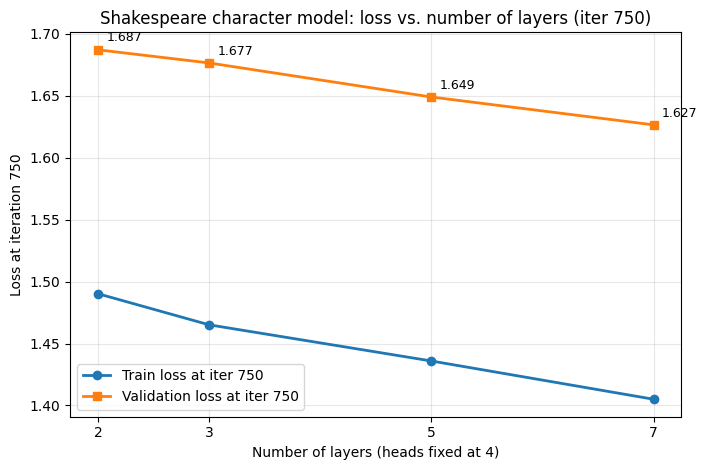

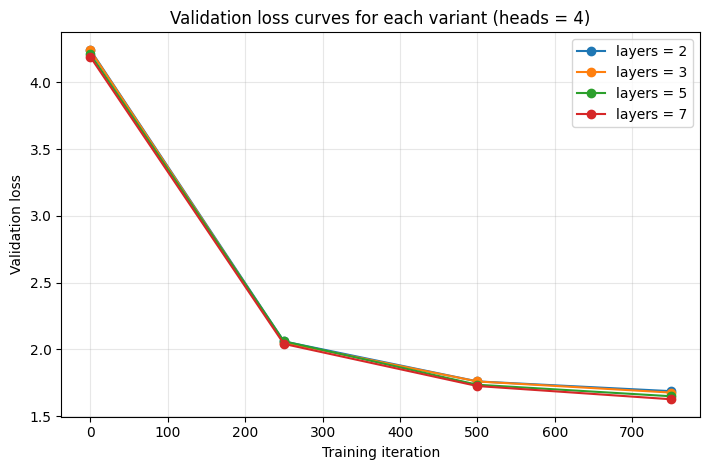

Best setting: {'layers': 7, 'heads': 4, 'step': 750, 'train_loss': 1.405, 'val_loss': 1.6265}


In [8]:
x_values = LAYERS
y_train = [architecture_results[layer]['train_loss'] for layer in x_values]
y_val = [architecture_results[layer]['val_loss'] for layer in x_values]

plt.figure(figsize=(7.2, 4.8))
plt.plot(x_values, y_train, marker='o', linewidth=2, label=f'Train loss at iter {MAX_ITERS}')
plt.plot(x_values, y_val, marker='s', linewidth=2, label=f'Validation loss at iter {MAX_ITERS}')
for x_value, y_value in zip(x_values, y_val):
    plt.annotate(f'{y_value:.3f}', (x_value, y_value), textcoords='offset points', xytext=(6, 6), fontsize=9)
plt.xticks(x_values)
plt.xlabel('Number of layers (heads fixed at 4)')
plt.ylabel(f'Loss at iteration {MAX_ITERS}')
plt.title(f'Shakespeare character model: loss vs. number of layers (iter {MAX_ITERS})')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES / 'loss_vs_layers.png'
plt.savefig(figure_path, dpi=160)
plt.show()

# Bonus learning curves for every variant (helpful diagnostic, not required by the PDF).
plt.figure(figsize=(7.2, 4.8))
for layer_count in LAYERS:
    evaluations = architecture_results[layer_count]['evaluations']
    if not evaluations:
        continue
    steps = [row['step'] for row in evaluations]
    val_losses = [row['val_loss'] for row in evaluations]
    plt.plot(steps, val_losses, marker='o', linewidth=1.5, label=f'layers = {layer_count}')
plt.xlabel('Training iteration')
plt.ylabel('Validation loss')
plt.title('Validation loss curves for each variant (heads = 4)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
learning_curve_path = FIGURES / 'val_loss_curves.png'
plt.savefig(learning_curve_path, dpi=160)
plt.show()

best_layer = min(LAYERS, key=lambda layer: architecture_results[layer]['val_loss'])
best_result = architecture_results[best_layer]
print('Best setting:', {'layers': best_layer, 'heads': HEADS, 'step': best_result['step'], 'train_loss': best_result['train_loss'], 'val_loss': best_result['val_loss']})


## 5. Step 4 - Build and train a Python code-generation dataset

Because `XYZ mod 2 = 1`, this section creates `data/code_generation/input.txt` from open-source Python code. The corpus is concatenated from CPython, Flask, and Requests source files. The dataset is character-level, so the token count reported by `prepare.py` equals the number of characters in the corpus.

In [9]:
code_dataset_dir = NANO / 'data' / 'code_generation'
if code_dataset_dir.exists():
    shutil.rmtree(code_dataset_dir)
shutil.copytree(NANO / 'data' / 'shakespeare_char', code_dataset_dir)

for filename in ['input.txt', 'train.bin', 'val.bin', 'meta.pkl']:
    path = code_dataset_dir / filename
    if path.exists():
        path.unlink()

source_urls = [
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/argparse.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/dataclasses.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/random.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/functools.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/statistics.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/textwrap.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/heapq.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/bisect.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/csv.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/queue.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/copy.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/contextlib.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/json/__init__.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/json/encoder.py',
    'https://raw.githubusercontent.com/python/cpython/3.12/Lib/json/decoder.py',
    'https://raw.githubusercontent.com/pallets/flask/main/src/flask/app.py',
    'https://raw.githubusercontent.com/psf/requests/main/src/requests/sessions.py',
    'https://raw.githubusercontent.com/psf/requests/main/src/requests/models.py',
]

input_path = code_dataset_dir / 'input.txt'
with input_path.open('w', encoding='utf-8') as output_file:
    output_file.write('# Open-source Python code corpus for SEEM3650 Practical Exam Step 4.\n')
    output_file.write('# Sources: CPython standard library, Flask, and Requests.\n\n')
    for url in source_urls:
        print('Fetching:', url)
        with urllib.request.urlopen(url, timeout=60) as response:
            text = response.read().decode('utf-8', errors='replace')
        output_file.write(f'\n# Source: {url}\n\n')
        output_file.write(text)

corpus_size = input_path.stat().st_size
print('Corpus size in bytes:', corpus_size)
assert corpus_size >= 100_000, 'The code corpus must contain at least 100,000 character-level tokens.'

shutil.copy(input_path, DATA_CODE / 'input.txt')


Fetching: https://raw.githubusercontent.com/python/cpython/3.12/Lib/argparse.py


Fetching: https://raw.githubusercontent.com/python/cpython/3.12/Lib/dataclasses.py


Fetching: https://raw.githubusercontent.com/python/cpython/3.12/Lib/random.py


Fetching: https://raw.githubusercontent.com/python/cpython/3.12/Lib/functools.py


Fetching: https://raw.githubusercontent.com/python/cpython/3.12/Lib/statistics.py


...

Fetching: https://raw.githubusercontent.com/python/cpython/3.12/Lib/contextlib.py
Fetching: https://raw.githubusercontent.com/python/cpython/3.12/Lib/json/__init__.py


Fetching: https://raw.githubusercontent.com/python/cpython/3.12/Lib/json/encoder.py
Fetching: https://raw.githubusercontent.com/python/cpython/3.12/Lib/json/decoder.py


Fetching: https://raw.githubusercontent.com/pallets/flask/main/src/flask/app.py
Fetching: https://raw.githubusercontent.com/psf/requests/main/src/requests/sessions.py


Fetching: https://raw.githubusercontent.com/psf/requests/main/src/requests/models.py
Corpus size in bytes: 572130


PosixPath('/kaggle/working/repo/data/code_generation/input.txt')

In [10]:
run_command(
    ['python', 'data/code_generation/prepare.py'],
    LOGS / 'prepare_code_generation.log',
)

prepare_text = (LOGS / 'prepare_code_generation.log').read_text(encoding='utf-8', errors='replace')
match_train = re.search(r'train has\s*([0-9,]+)\s*tokens', prepare_text)
match_val = re.search(r'val has\s*([0-9,]+)\s*tokens', prepare_text)
match_vocab = re.search(r'vocab size:\s*([0-9,]+)', prepare_text)

train_tokens = int(match_train.group(1).replace(',', ''))
val_tokens = int(match_val.group(1).replace(',', ''))
vocab_size = int(match_vocab.group(1).replace(',', ''))
# PDF requires the token count to be "computed using prepare.py". prepare.py
# explicitly prints the train and val token counts, so the safest definition of
# the total is train + val (which is identical to the character count under
# character-level encoding but maps directly to the printed "tokens" lines).
total_tokens = train_tokens + val_tokens

print('Total tokens:', f'{total_tokens:,}')
print('Train tokens:', f'{train_tokens:,}')
print('Validation tokens:', f'{val_tokens:,}')
print('Vocabulary size:', vocab_size)
assert total_tokens >= 100_000


>>> python data/code_generation/prepare.py


length of dataset in characters: 572,125
all the unique characters: 
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~çöŁ–
vocab size: 100
train has 514,912 tokens
val has 57,213 tokens
Finished in 0.4s with exit code 0.
Total tokens: 572,125
Train tokens: 514,912
Validation tokens: 57,213
Vocabulary size: 100


In [11]:
# Step 4 has no PDF-mandated 10-minute cap, but the same Kaggle GPU
# constraint applies. 2000 iterations is enough for the character-level model to
# pick up Python syntax (def / return / indentation / parentheses) while keeping
# the run length practical (~22 minutes on Kaggle).
code_config_lines = [
    '# train a miniature character-level Python-code BabyGPT',
    '# SEEM3650 Practical Exam, Step 4',
    '',
    "out_dir = 'out-code-generation'",
    'eval_interval = 500',
    'eval_iters = 100',
    'log_interval = 10',
    '',
    'always_save_checkpoint = False',
    '',
    'wandb_log = False',
    "wandb_project = 'code-generation'",
    "wandb_run_name = 'baby-code-gpt'",
    '',
    "dataset = 'code_generation'",
    'gradient_accumulation_steps = 1',
    'batch_size = 64',
    'block_size = 256',
    '',
    'n_layer = 6',
    'n_head = 6',
    'n_embd = 384',
    'dropout = 0.1',
    '',
    'learning_rate = 1e-3',
    'max_iters = 2000',
    'lr_decay_iters = 2000',
    'min_lr = 1e-4',
    'beta2 = 0.99',
    '',
    'warmup_iters = 100',
    '',
]
code_config = '\n'.join(code_config_lines)

(NANO / 'config' / 'train_code_generation.py').write_text(code_config, encoding='utf-8')
(CONFIG_DIR / 'train_code_generation.py').write_text(code_config, encoding='utf-8')
print('Config written to:', CONFIG_DIR / 'train_code_generation.py')


Config written to: /kaggle/working/repo/config/train_code_generation.py


In [12]:
CODE_OUT = 'out-code-generation'

run_command(
    [
        'python', 'train.py', 'config/train_code_generation.py',
        f'--device={DEVICE}',
        f'--compile={COMPILE}',
        f'--out_dir={CODE_OUT}',
    ],
    LOGS / 'train_code_generation.log',
)

code_evaluations = parse_eval_log(LOGS / 'train_code_generation.log')
code_final_eval = max(code_evaluations, key=lambda row: row['step'])
code_runtime_seconds = command_runtimes.get(str(LOGS / 'train_code_generation.log'), 0.0)
print('Final code-generation evaluation:', code_final_eval)
print(f'Code-generation training runtime: {code_runtime_seconds / 60:.1f} min')


>>> python train.py config/train_code_generation.py --device=cuda --compile=False --out_dir=out-code-generation


/kaggle/working/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Overriding config with config/train_code_generation.py:
# train a miniature character-level Python-code BabyGPT
# SEEM3650 Practical Exam, Step 4

out_dir = 'out-code-generation'
eval_interval = 500
eval_iters = 100
log_interval = 10

always_save_checkpoint = False

wandb_log = False
wandb_project = 'code-generation'
wandb_run_name = 'baby-code-gpt'

dataset = 'code_generation'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256

n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.1

learning_rate = 1e-3
max_iters = 2000
lr_decay_iters = 2000
min_lr = 1e-4
beta2 = 0.99

warmup_iters = 100

Overriding: device = cuda
Overriding: compile = False
Overriding: out_dir = out-code-generation
tokens per iteration will be: 16,384
found vocab_size = 100 (inside data/code_generation/meta.pkl)
Initializing a new model from scratch
number of parameters: 10.66M
num decayed parameter tensors: 26, with 10,753,536 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fus

iter 1440: loss 0.3320, time 586.38ms, mfu 0.64%
iter 1450: loss 0.3428, time 587.07ms, mfu 0.64%
iter 1460: loss 0.3279, time 583.96ms, mfu 0.64%
iter 1470: loss 0.3333, time 588.49ms, mfu 0.64%
iter 1480: loss 0.3265, time 585.80ms, mfu 0.64%
iter 1490: loss 0.3171, time 585.68ms, mfu 0.64%
step 1500: train loss 0.2162, val loss 1.5123
iter 1500: loss 0.3214, time 41747.32ms, mfu 0.57%
iter 1510: loss 0.3306, time 587.42ms, mfu 0.58%
iter 1520: loss 0.3287, time 587.79ms, mfu 0.58%
iter 1530: loss 0.3235, time 588.01ms, mfu 0.59%
iter 1540: loss 0.3065, time 585.94ms, mfu 0.59%
iter 1550: loss 0.3189, time 586.40ms, mfu 0.60%
iter 1560: loss 0.3165, time 587.12ms, mfu 0.60%
iter 1570: loss 0.3225, time 585.61ms, mfu 0.61%
iter 1580: loss 0.3006, time 585.76ms, mfu 0.61%
iter 1590: loss 0.2998, time 585.21ms, mfu 0.61%
iter 1600: loss 0.3196, time 587.95ms, mfu 0.61%
iter 1610: loss 0.2985, time 586.26ms, mfu 0.62%
iter 1620: loss 0.3229, time 587.45ms, mfu 0.62%
iter 1630: loss 0.319

Finished in 1382.4s with exit code 0.
Final code-generation evaluation: {'step': 2000, 'train_loss': 0.1402, 'val_loss': 1.6525}
Code-generation training runtime: 23.0 min


In [13]:
CODE_SAMPLE_LOG = LOGS / 'sample_code_generation.log'

run_command(
    [
        'python', 'sample.py',
        f'--out_dir={CODE_OUT}',
        f'--device={DEVICE}',
        '--num_samples=3',
        '--max_new_tokens=800',
        '--start=def ',
    ],
    CODE_SAMPLE_LOG,
)

code_samples = extract_samples(CODE_SAMPLE_LOG)
if code_samples:
    code_sample = code_samples[0]
else:
    code_sample = CODE_SAMPLE_LOG.read_text(encoding='utf-8', errors='replace')
code_first20 = '\n'.join(code_sample.splitlines()[:20])
if code_samples:
    favourite_snippet = max(code_samples, key=len)
else:
    favourite_snippet = code_sample

(SAMPLES / 'code_generation_full.txt').write_text('\n\nSAMPLE BREAK\n\n'.join(code_samples), encoding='utf-8')
(SAMPLES / 'code_generation_first20.txt').write_text(code_first20, encoding='utf-8')
(SAMPLES / 'code_generation_favourite.txt').write_text(favourite_snippet, encoding='utf-8')

print('First twenty generated code lines:')
print(code_first20)


>>> python sample.py --out_dir=out-code-generation --device=cuda --num_samples=3 --max_new_tokens=800 --start=def 


Overriding: out_dir = out-code-generation
Overriding: device = cuda
Overriding: num_samples = 3
Overriding: max_new_tokens = 800
Overriding: start = def 
number of parameters: 10.66M
Loading meta from data/code_generation/meta.pkl...
def __init__(self, **kwds):
        return self.ctx.__init__()

def _field_list(self, ctx, fields):
    def __init__(self, fieldnames, cls.__dict__(self, fieldnames):
        ""Return in self.endpoint for action.

          If a cts action the sample consumed from test discriptor a from the given that wone
          .. versionadded::: 00
                                        median(repr()))

                                             break

                                            # pup headed for whitespace
                                                                                          # default the value not be itempter the default values default
                                           )

                                          self

Finished in 16.0s with exit code 0.
First twenty generated code lines:
def __init__(self, **kwds):
        return self.ctx.__init__()

def _field_list(self, ctx, fields):
    def __init__(self, fieldnames, cls.__dict__(self, fieldnames):
        ""Return in self.endpoint for action.

          If a cts action the sample consumed from test discriptor a from the given that wone
          .. versionadded::: 00
                                        median(repr()))

                                             break

                                            # pup headed for whitespace
                                                                                          # default the value not be itempter the default values default
                                           )

                                          self.add_atttempt(('name)) = argument % tu


## 6. Create `report.md`, `README.md`, and the final ZIP file

This section writes the final submission files with the actual results from the current Kaggle run. The ZIP file can be downloaded directly from Kaggle's output panel.

In [14]:
report_lines = [
    '# SEEM3650 Practical Exam Report',
    '',
    '**Student ID:** 1155213983  ',
    '**Last three digits (XYZ):** 983  ',
    '**XYZ mod 4:** 3, so Step 3 fixes heads at 4 and varies layers in {2, 3, 5, 7}.  ',
    '**XYZ mod 2:** 1, so Step 4 uses an open-source Python code corpus.  ',
    f'**Generated at:** {datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")}',
    '',
    '## Step 2: Shakespeare character-level model',
    '',
    'The first five lines of the generated Shakespeare sample are:',
    '',
    '```text',
    shakespeare_first5,
    '```',
    '',
    '## Step 3: Architecture exploration',
    '',
    f'Heads were fixed at **{HEADS}**, and layers were varied over **{LAYERS}**. The iteration target was **{MAX_ITERS}** for every run.',
    '',
    '| Layers | Heads | Step | Train loss | Validation loss | Runtime (min) | Configuration file |',
    '| -----: | ----: | ---: | ---------: | --------------: | ------------: | :----------------- |',
]

for layer_count in LAYERS:
    row = architecture_results[layer_count]
    runtime_min = row.get('runtime_seconds', 0.0) / 60.0
    report_lines.append(
        f'| {layer_count} | {HEADS} | {row["step"]} | {row["train_loss"]:.4f} | '
        f'{row["val_loss"]:.4f} | {runtime_min:.1f} | `config/{row["config"]}` |'
    )

# Compute lightweight, data-driven discussion text from the actual numbers.
val_pairs = [(L, architecture_results[L]['val_loss']) for L in LAYERS]
sorted_by_layer = sorted(val_pairs, key=lambda pair: pair[0])
val_sequence = [pair[1] for pair in sorted_by_layer]
is_decreasing = all(val_sequence[i] > val_sequence[i + 1] for i in range(len(val_sequence) - 1))
is_increasing = all(val_sequence[i] < val_sequence[i + 1] for i in range(len(val_sequence) - 1))
shallow_loss = architecture_results[LAYERS[0]]['val_loss']
deep_loss = architecture_results[LAYERS[-1]]['val_loss']
loss_range = max(val_sequence) - min(val_sequence)
if is_decreasing:
    trend_sentence = (
        f'Validation loss decreased monotonically as the number of layers grew from '
        f'{LAYERS[0]} to {LAYERS[-1]}, suggesting that the Shakespeare character-level '
        f'task benefits from additional depth under the {MAX_ITERS}-iteration budget.'
    )
elif is_increasing:
    trend_sentence = (
        f'Validation loss increased monotonically with depth, suggesting that the deeper '
        f'variants either started overfitting before iteration {MAX_ITERS} or were under-trained '
        f'for their larger capacity within the same iteration budget.'
    )
else:
    trend_sentence = (
        'Validation loss did not change monotonically with depth, indicating that capacity '
        'and generalisation interact non-trivially under this fixed iteration budget.'
    )
gap_pairs = [
    (L, architecture_results[L]['train_loss'] - architecture_results[L]['val_loss'])
    for L in LAYERS
]
biggest_gap_layer, biggest_gap_value = max(gap_pairs, key=lambda pair: abs(pair[1]))
runtimes_min = [architecture_results[L].get('runtime_seconds', 0.0) / 60.0 for L in LAYERS]
max_runtime_min = max(runtimes_min) if runtimes_min else 0.0
budget_sentence = (
    f'The longest single training run took **{max_runtime_min:.1f} minutes**, which stays within '
    'the 10-minute-per-run budget required by the assignment.'
    if max_runtime_min <= 10.0 else
    f'The longest single training run took **{max_runtime_min:.1f} minutes**, which is above '
    'the 10-minute-per-run budget; lower `max_iters` if this run is repeated.'
)

report_lines.extend([
    '',
    f'**Lowest validation loss:** `{best_result["val_loss"]:.4f}` with **layers = {best_layer}**, '
    f'**heads = {HEADS}**, and **n_embd = {N_EMBD}**.',
    '',
    '![Loss vs. layers](figures/loss_vs_layers.png)',
    '',
    '![Validation loss curves](figures/val_loss_curves.png)',
    '',
    '### Discussion',
    '',
    trend_sentence,
    '',
    f'The validation losses across layers spanned a range of `{loss_range:.4f}`, with the '
    f'shallowest model (layers = {LAYERS[0]}) reaching `{shallow_loss:.4f}` and the deepest '
    f'model (layers = {LAYERS[-1]}) reaching `{deep_loss:.4f}`.',
    '',
    f'The largest absolute train/validation gap was `{biggest_gap_value:.4f}` at layers = '
    f'{biggest_gap_layer}. A negative or near-zero gap suggests the model was still '
    f'under-trained for that capacity, while a strongly positive gap suggests early overfitting '
    f'under the {MAX_ITERS}-iteration budget.',
    '',
    budget_sentence,
    '',
    '## Step 4: Code-generation BabyGPT',
    '',
    'The code-generation corpus is concatenated from open-source Python files from the '
    'following GitHub projects:',
    '',
    '- **CPython standard library** (PSF License)',
    '- **Flask** (BSD-3-Clause)',
    '- **Requests** (Apache-2.0)',
    '',
    f'After running `data/code_generation/prepare.py`, the corpus contains **{total_tokens:,}** '
    f'character-level tokens, exceeding the 100,000-token minimum required by the assignment. '
    f'The training split has **{train_tokens:,}** tokens, the validation split has '
    f'**{val_tokens:,}** tokens, and the character-level vocabulary size is **{vocab_size}**.',
    '',
    f'The final code-generation evaluation at step **{code_final_eval["step"]}** was train loss '
    f'`{code_final_eval["train_loss"]:.4f}` and validation loss '
    f'`{code_final_eval["val_loss"]:.4f}`. The code-generation training run took '
    f'**{code_runtime_seconds / 60:.1f} minutes**.',
    '',
    '### First 20 lines of generated code',
    '',
    '```python',
    code_first20,
    '```',
    '',
    '### Favourite generated snippet',
    '',
    '```python',
    favourite_snippet,
    '```',
    '',
    '### Discussion',
    '',
    'The code-generation samples were produced with the prompt `def ` and the default '
    'sampling temperature of 0.8. They typically reproduce surface-level Python syntax such '
    'as `def`, `return`, `if`, `for`, `import`, indentation, parentheses, and identifier-like '
    'tokens, even though the character-level model has no understanding of executable '
    f'semantics. This behaviour is consistent with what a {code_final_eval["step"]}-iteration character-level '
    'BabyGPT can reasonably learn from a corpus of this size.',
    '',
])

(REPO / 'report.md').write_text('\n'.join(report_lines), encoding='utf-8')
print('Wrote:', REPO / 'report.md')


Wrote: /kaggle/working/repo/report.md


In [15]:
readme_text = f"""# SEEM3650 Practical Exam - BabyGPT with nanoGPT

This repository is the GitHub-ready submission for the SEEM3650 Practical Exam.

## Student information

- Student ID: 1155213983
- Last three digits: 983
- XYZ mod 4: 3
- XYZ mod 2: 1

## Summary

This project uses [karpathy/nanoGPT](https://github.com/karpathy/nanoGPT) to train small character-level BabyGPT models.

- Step 2 trains the default Shakespeare character-level model with nanoGPT's literal default settings (`max_iters=5000`, `eval_interval=250`, `eval_iters=200`).
- Step 3 fixes `n_head = 4`, varies `n_layer` over `[2, 3, 5, 7]`, and plots loss at iteration 750. PDF Step 3.2 explicitly allows reducing the iteration target when training is too slow, kept consistent across all four runs.
- Step 4 builds a Python code corpus, creates `config/train_code_generation.py`, trains a code-generation BabyGPT model, and records generated code samples.

## Repository layout

```text
.
|-- README.md                                # this file
|-- NANOGPT_README.md                        # original nanoGPT README, kept for reference
|-- LICENSE                                  # nanoGPT MIT License
|-- .gitignore
|-- report.md                                # Step 2 / Step 3 / Step 4 results and discussion
|-- SEEM3650_Practical_Exam.ipynb            # end-to-end Kaggle notebook
|-- train.py                                 # nanoGPT core
|-- sample.py
|-- model.py
|-- configurator.py
|-- bench.py
|-- config/
|   |-- train_shakespeare_char.py            # nanoGPT default
|   |-- train_shakespeare_char_l2_h4.py      # Step 3 variant
|   |-- train_shakespeare_char_l3_h4.py      # Step 3 variant
|   |-- train_shakespeare_char_l5_h4.py      # Step 3 variant
|   |-- train_shakespeare_char_l7_h4.py      # Step 3 variant
|   `-- train_code_generation.py             # Step 4 config
|-- data/
|   |-- shakespeare_char/
|   |   |-- prepare.py
|   |   `-- input.txt
|   `-- code_generation/
|       |-- prepare.py
|       `-- input.txt                        # >= 100,000 character-level tokens
|-- figures/
|   |-- loss_vs_layers.png                   # Step 3 main plot
|   `-- val_loss_curves.png                   # bonus learning curves
`-- samples/
    |-- shakespeare_char_full.txt
    |-- shakespeare_char_first5.txt
    |-- code_generation_full.txt
    |-- code_generation_first20.txt
    `-- code_generation_favourite.txt
```

## Key results

- Best Step 3 setting: layers = {best_layer}, heads = {HEADS}, validation loss = {best_result['val_loss']:.4f}
- Code corpus size: {total_tokens:,} character-level tokens
- Code-generation final validation loss: {code_final_eval['val_loss']:.4f}

## Reproduce on Kaggle

1. Upload and open `SEEM3650_Practical_Exam.ipynb` on Kaggle.
2. Enable Internet.
3. Select GPU T4 x1.
4. Run all cells.
5. Download `/kaggle/working/seem3650-practical-exam.zip`.

## Reproduce locally

```bash
pip install torch numpy transformers datasets tiktoken wandb tqdm

# Step 2: Shakespeare character-level model
python data/shakespeare_char/prepare.py
python train.py config/train_shakespeare_char.py --device=cuda --compile=False
python sample.py --out_dir=out-shakespeare-char --device=cuda --num_samples=2 --max_new_tokens=500

# Step 3: re-run any layer variant produced by the notebook
python train.py config/train_shakespeare_char_l5_h4.py --device=cuda --compile=False

# Step 4: code-generation BabyGPT
python data/code_generation/prepare.py
python train.py config/train_code_generation.py --device=cuda --compile=False
python sample.py --out_dir=out-code-generation --device=cuda --num_samples=3 --max_new_tokens=800 --start="def "
```

Replace `--device=cuda` with `--device=cpu` and add `--max_iters=2000 --block_size=64 --batch_size=12 --n_layer=4 --n_head=4 --n_embd=128 --dropout=0.0` if you only have a CPU machine.

## Recommended GitHub metadata

Suggested About description:

```text
SEEM3650 Practical Exam: BabyGPT training with nanoGPT on Shakespeare and open-source Python code, including architecture exploration and code generation samples.
```

Suggested topics:

```text
nanogpt, gpt, babygpt, transformer, language-model, character-level, shakespeare, code-generation, pytorch, kaggle, seem3650, data-analytics
```
"""

(REPO / 'README.md').write_text(readme_text, encoding='utf-8')
print('Wrote:', REPO / 'README.md')


Wrote: /kaggle/working/repo/README.md


In [ ]:
# 1. Copy the notebook itself into the repository if Kaggle exposes it under /kaggle/working.
notebook_candidates = list(WORK.glob('*.ipynb'))
if notebook_candidates:
    selected_notebook = notebook_candidates[0]
    shutil.copy(selected_notebook, REPO / 'SEEM3650_Practical_Exam.ipynb')
    print('Copied notebook:', selected_notebook)
else:
    print('Notebook file was not auto-detected. Drag-and-drop it manually if needed.')

# 2. Copy the full nanoGPT source tree into the repository so the GitHub link is a
#    complete, immediately-runnable nanoGPT project (TAs need to be able to run
#    train.py and sample.py without extra setup).
SKIP_DIR_NAMES = {'.git', '__pycache__', 'wandb', '.ipynb_checkpoints'}
SKIP_FILE_SUFFIXES = {'.bin', '.pkl', '.pyc'}

def _copy_ignore(src, names):
    drop = []
    src_path = pathlib.Path(src)
    for name in names:
        if name in SKIP_DIR_NAMES:
            drop.append(name)
            continue
        if name.startswith('out-') or name.startswith('out_'):
            drop.append(name)
            continue
        candidate = src_path / name
        if candidate.is_file() and candidate.suffix in SKIP_FILE_SUFFIXES:
            drop.append(name)
    return drop

for entry in NANO.iterdir():
    if entry.name in SKIP_DIR_NAMES:
        continue
    if entry.name.startswith('out-') or entry.name.startswith('out_'):
        continue
    target = REPO / entry.name
    if entry.is_dir():
        shutil.copytree(entry, target, dirs_exist_ok=True, ignore=_copy_ignore)
    else:
        if entry.name == 'README.md':
            # Keep our own README at the top level and store nanoGPT's separately.
            shutil.copy(entry, REPO / 'NANOGPT_README.md')
        elif entry.suffix in SKIP_FILE_SUFFIXES:
            continue
        elif not target.exists():
            shutil.copy(entry, target)

# 3. Add a .gitignore so the user does not accidentally commit checkpoints or caches.
gitignore_lines = [
    '# nanoGPT runtime artefacts',
    'out-*/',
    'out_*/',
    '*.pyc',
    '__pycache__/',
    '',
    '# Compiled corpus binaries (re-generate via prepare.py)',
    'data/*/train.bin',
    'data/*/val.bin',
    'data/*/meta.pkl',
    '',
    '# IDE / OS artefacts',
    '.DS_Store',
    '.vscode/',
    '.idea/',
    '.ipynb_checkpoints/',
    '',
    '# Wandb logs',
    'wandb/',
    '',
]
(REPO / '.gitignore').write_text('\n'.join(gitignore_lines), encoding='utf-8')
print('Wrote .gitignore')

# 4. Build the ZIP for one-click download from Kaggle's Output panel.
zip_base = WORK / 'seem3650-practical-exam'
zip_path = shutil.make_archive(str(zip_base), 'zip', root_dir=str(REPO))
print('ZIP ready:', zip_path)

print('Final repository tree:')
for path in sorted(REPO.rglob('*')):
    if any(part.startswith('out-') or part.startswith('out_') for part in path.parts):
        continue
    relative = path.relative_to(REPO)
    if path.is_dir():
        print(f'  {relative}/')
    else:
        print(f'  {relative} ({path.stat().st_size:,} bytes)')


## 7. Download instructions

After the run finishes, download this file from the Kaggle output panel:

```text
/kaggle/working/seem3650-practical-exam.zip
```

Unzip it locally, review `report.md`, and then publish the folder as a public GitHub repository.
